# Knowledge Tracing: BKT baseline vs. AKT prototype

Compares two knowledge-tracing models on this project's student interaction graph, to
decide what backs the personalization system's per-topic mastery estimates.

- **BKT** (Bayesian Knowledge Tracing) — one 2-state HMM per (student, leaf topic),
  updated online per attempt. Cheap, interpretable, standard for tutoring systems at
  small-to-medium data scale.
- **AKT** (Attentive Knowledge Tracing) — transformer-based deep KT, attends over a
  student's full interaction sequence. State of the art on large benchmarks (millions of
  interactions), but needs a lot of data to learn anything beyond what a simpler model
  already captures.

Data: `scripts/generate_dummy_interactions.py`'s synthetic students, generated against
the real question bank's subject/topic taxonomy (`notebooks/mcq_output/question_bank.json`)
so topic-level sequences here have the same shape production data will have. Current scale:
20 students, ~1100 quiz answers, 56 simulated topics — enough to fit BKT meaningfully, and
explicitly NOT enough to fit AKT meaningfully. The AKT section is included to make that
gap concrete (learning curves, degenerate attention), not because AKT is expected to win
here — see the comparison section at the end for the actual recommendation.

Requires `make neo4j-up` and the dummy data already generated (see
`docs/07-operations.md` / this repo's README).

In [1]:
import math
import random
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from dotenv import load_dotenv
from sklearn.metrics import roc_auc_score, log_loss

PROJECT_ROOT = Path.cwd().parent  # notebook lives in notebooks/
sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")

from src.student_kg.driver import make_driver

pd.set_option("display.max_rows", 20)
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

device: mps


## 1. Pull interaction sequences from Neo4j

One row per `QUIZ_ANSWER` event, joined to the leaf `Topic` it's tagged with via
`(:Question)-[:BELONGS_TO]->(:Topic)` (see `src/quiz/attempts.py::record_attempt` — the
leaf topic is the deepest element of `topic_tag`). Ordered by `ts` within each student so
sequence models see the real chronological order.

In [2]:
_SEQUENCES_QUERY = """
MATCH (s:Student)-[:ATTEMPTED]->(:QuizSession)-[:HAS_ANSWER]->(e:InteractionEvent {type: "QUIZ_ANSWER"})
MATCH (e)-[:FOR_QUESTION]->(q:Question)-[:BELONGS_TO]->(t:Topic)
RETURN s.id AS student_id, t.path AS topic_path, e.question_uid AS question_uid,
       e.correct AS correct, e.confidence AS confidence,
       e.time_taken_seconds AS time_taken_seconds, e.ts AS ts
ORDER BY s.id, e.ts ASC
"""

driver = make_driver()
with driver.session() as session:
    records = [dict(r) for r in session.run(_SEQUENCES_QUERY)]
driver.close()

df = pd.DataFrame(records)
df["ts"] = df["ts"].apply(lambda z: z.to_native())
df["correct"] = df["correct"].astype(int)
print(f"{len(df)} attempts, {df.student_id.nunique()} students, {df.topic_path.nunique()} topics")
df.head()

1102 attempts, 20 students, 56 topics


,student_id,topic_path,question_uid,correct,confidence,time_taken_seconds,ts
0,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 02 2024 rc > Enzyme activity and sub...,master_mcq::copy_of_paket_a46_pdf::0005,1,unsure,26.67,2026-03-11 00:01:48.521909+00:00
1,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 02 2024 rc > Enzyme activity and sub...,master_mcq::salinan_paket_c22_pdf::0005,1,unsure,23.33,2026-03-11 00:03:26.594681+00:00
2,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 02 2024 rc > Enzyme activity and sub...,master_mcq::paket_42_pdf::0003,1,unsure,23.01,2026-03-11 00:04:46.879666+00:00
3,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 02 2024 rc > Enzyme activity and sub...,master_mcq::copy_of_paket_a1_pdf::0005,1,confident,11.15,2026-03-11 00:08:42.256410+00:00
4,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 02 2024 rc > Enzyme activity and sub...,master_mcq::copy_of_paket_a46_pdf::0005,0,unsure,9.80,2026-03-11 00:10:07.918302+00:00


In [3]:
# Data-scale diagnostics up front — these numbers are what make the BKT-vs-AKT call later.
attempts_per_student_topic = df.groupby(["student_id", "topic_path"]).size()
print("attempts per (student, topic) pair:")
print(attempts_per_student_topic.describe())
print()
print("median attempts/student/topic:", attempts_per_student_topic.median())
print("pairs with >=5 attempts:", (attempts_per_student_topic >= 5).sum(),
      "/", len(attempts_per_student_topic))

attempts per (student, topic) pair:
count    184.000000
mean       5.989130
std        2.427054
min        3.000000
25%        4.000000
50%        6.000000
75%        8.000000
max       19.000000
dtype: float64

median attempts/student/topic: 6.0
pairs with >=5 attempts: 128 / 184


## 2. BKT baseline

Standard 2-state (knows / doesn't-know) HMM per (student, topic):

- `p_init` — prior P(knows) before any evidence.
- `p_transit` — P(learns) between an unknown state and the next attempt.
- `p_slip` — P(wrong | knows).
- `p_guess` — P(correct | doesn't know).

Update rule (per attempt, standard BKT posterior + learning-transition step):

```
p_correct_given_know    = 1 - p_slip
p_correct_given_not_know = p_guess

if observed correct:
    p_know_post = p_know * p_correct_given_know / (p_know * p_correct_given_know + (1-p_know) * p_correct_given_not_know)
else:
    p_know_post = p_know * p_slip / (p_know * p_slip + (1-p_know) * (1-p_guess))

p_know_next = p_know_post + (1 - p_know_post) * p_transit
```

Global params here are fixed defaults (not per-topic fit via EM) — reasonable for a first
pass; EM-fitting `p_slip`/`p_guess`/`p_transit` per topic is listed as follow-up work at
the end.

In [4]:
BKT_PARAMS = dict(p_init=0.3, p_transit=0.1, p_slip=0.1, p_guess=0.25)


def bkt_update(p_know: float, correct: bool, params: dict) -> float:
    p_slip, p_guess, p_transit = params["p_slip"], params["p_guess"], params["p_transit"]
    if correct:
        num = p_know * (1 - p_slip)
        denom = num + (1 - p_know) * p_guess
    else:
        num = p_know * p_slip
        denom = num + (1 - p_know) * (1 - p_guess)
    p_know_post = num / denom if denom > 0 else p_know
    return p_know_post + (1 - p_know_post) * p_transit


def bkt_predict_proba(p_know: float, params: dict) -> float:
    """P(correct) implied by current p_know, before seeing the observation."""
    return p_know * (1 - params["p_slip"]) + (1 - p_know) * params["p_guess"]


def run_bkt(df: pd.DataFrame, params: dict = BKT_PARAMS) -> tuple[pd.DataFrame, dict]:
    """Runs BKT forward over every (student, topic) sequence in chronological order.
    Returns per-attempt predicted P(correct) (predicted BEFORE the update, i.e. a genuine
    next-step prediction, not a fitted-in-hindsight one) and the final p_know per pair."""
    preds = np.empty(len(df))
    state: dict[tuple[str, str], float] = {}
    for i, row in enumerate(df.itertuples()):
        key = (row.student_id, row.topic_path)
        p_know = state.get(key, params["p_init"])
        preds[i] = bkt_predict_proba(p_know, params)
        state[key] = bkt_update(p_know, bool(row.correct), params)
    out = df.copy()
    out["bkt_pred"] = preds
    return out, state


df_sorted = df.sort_values(["student_id", "topic_path", "ts"]).reset_index(drop=True)
bkt_results, bkt_final_state = run_bkt(df_sorted)
bkt_results[["student_id", "topic_path", "ts", "correct", "bkt_pred"]].head(10)

,student_id,topic_path,ts,correct,bkt_pred
0,0597911b-0e08-477c-95a2-6f2eda2ccc56,Abdominal wall - hollow organ - organs > Abdom...,2026-03-18 11:06:09.809515+00:00,0,0.445000
1,0597911b-0e08-477c-95a2-6f2eda2ccc56,Abdominal wall - hollow organ - organs > Abdom...,2026-03-18 11:07:14.383310+00:00,1,0.346622
2,0597911b-0e08-477c-95a2-6f2eda2ccc56,Abdominal wall - hollow organ - organs > Abdom...,2026-03-18 11:09:13.214882+00:00,0,0.540789
3,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 01 2024 rc > Serum Enzyme Measurement,2026-04-01 08:45:26.962994+00:00,0,0.445000
4,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 01 2024 rc > Serum Enzyme Measurement,2026-04-01 08:48:58.530190+00:00,0,0.346622
5,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 01 2024 rc > Serum Enzyme Measurement,2026-04-01 08:52:12.831354+00:00,1,0.328309
6,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 02 2024 rc > Enzyme activity and sub...,2026-03-11 00:01:48.521909+00:00,1,0.445000
7,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 02 2024 rc > Enzyme activity and sub...,2026-03-11 00:03:26.594681+00:00,1,0.669944
8,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 02 2024 rc > Enzyme activity and sub...,2026-03-11 00:04:46.879666+00:00,1,0.822736
9,0597911b-0e08-477c-95a2-6f2eda2ccc56,ENZIME FK 02 2024 rc > Enzyme activity and sub...,2026-03-11 00:08:42.256410+00:00,1,0.878870


In [5]:
bkt_auc = roc_auc_score(bkt_results["correct"], bkt_results["bkt_pred"])
bkt_ll = log_loss(bkt_results["correct"], bkt_results["bkt_pred"].clip(1e-4, 1 - 1e-4))
print(f"BKT next-step prediction — AUC: {bkt_auc:.4f}, log loss: {bkt_ll:.4f}")

BKT next-step prediction — AUC: 0.6638, log loss: 0.6661


## 3. Final mastery snapshot (what the personalization system would actually read)

This is the shape a `MASTERS` edge (`Student -> Topic`, `p_know`) would take in the graph
— see the design note at the end for wiring this into `src/quiz/attempts.py::record_attempt`.

In [6]:
mastery_rows = [
    {"student_id": sid, "topic_path": tp, "p_know": pk}
    for (sid, tp), pk in bkt_final_state.items()
]
mastery_df = pd.DataFrame(mastery_rows)
mastery_df.sort_values("p_know").head(10)

,student_id,topic_path,p_know
32,1aa9a58a-e19b-4024-a227-c7861d65245e,Embriologi Pencernaan > Cleft palate causes,0.115385
174,fd103587-0e11-45d0-bf02-e85499029585,Anatomy of Endocrine Glands > Thymus and immun...,0.115385
95,59574284-4702-4b86-b33c-5790433db51b,karbohidrat > Carbohydrate digestion enzymes,0.115385
175,fd103587-0e11-45d0-bf02-e85499029585,Anatomy of Neck > Anatomy of Neck,0.115387
127,bbfca36d-4219-4e32-ac1d-0ab695a815a6,Gi Track Ii Rev 2026 > Glandular epithelial hi...,0.115387
75,4174d893-d602-4947-baba-628e32b1b220,Thyroid > Thyroid hormone synthesis,0.115390
13,06a0b289-5aeb-4e83-9106-6838034d5f96,karbohidrat > Carbohydrate metabolism,0.115401
79,4ac92a6f-e968-4e15-b083-a79ca929d0bb,ENZIME FK 02 2024 rc > Enzyme activity and sub...,0.115479
152,cab033ff-8b7c-40ac-bdf6-fb4dfaa66bd9,Endocrine 1-25 > Hormone structure classification,0.115497
140,c9083126-d8cf-47f0-a548-ed281a09c6db,ENZIME FK 01 2024 rc > Enzyme active site stru...,0.115497


## 4. AKT prototype

A minimal Attentive Knowledge Tracing model: question/topic embeddings + a causal
Transformer encoder over each student's interaction sequence, predicting P(correct) at
each step from everything before it. This is a simplified version of the AKT
architecture (Ghosh et al. 2020) — real AKT adds a monotonic, distance-aware attention
mechanism (Rasch-model-based question embeddings); this prototype uses plain causal
self-attention, which is enough to show the data-scale problem without the extra
complexity.

In [7]:
topic_ids = {t: i for i, t in enumerate(sorted(df["topic_path"].unique()))}
n_topics = len(topic_ids)
print("n_topics:", n_topics)

MAX_SEQ_LEN = 64


def build_sequences(df: pd.DataFrame) -> list[dict]:
    """One sequence per student: topic ids + correctness, chronologically ordered,
    truncated to the most recent MAX_SEQ_LEN interactions."""
    seqs = []
    for sid, g in df.sort_values("ts").groupby("student_id"):
        topics = [topic_ids[t] for t in g["topic_path"]]
        corrects = list(g["correct"])
        if len(topics) < 2:
            continue  # need at least one prior interaction to predict the next
        topics = topics[-MAX_SEQ_LEN:]
        corrects = corrects[-MAX_SEQ_LEN:]
        seqs.append({"student_id": sid, "topics": topics, "corrects": corrects})
    return seqs


sequences = build_sequences(df_sorted)
seq_lens = [len(s["topics"]) for s in sequences]
print(f"{len(sequences)} student sequences, length min/median/max: "
      f"{min(seq_lens)}/{int(np.median(seq_lens))}/{max(seq_lens)}")

n_topics: 56
20 student sequences, length min/median/max: 15/56/64


In [8]:
class AKTDataset(torch.utils.data.Dataset):
    """Each item is one student's full sequence, padded to MAX_SEQ_LEN. Input at step i is
    (topic_i, correct_{i-1}) — the interaction embedding uses the PREVIOUS response, since
    predicting step i's correctness from step i's own answer would be leakage."""

    def __init__(self, sequences, max_len=MAX_SEQ_LEN):
        self.sequences = sequences
        self.max_len = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        topics = seq["topics"]
        corrects = seq["corrects"]
        L = len(topics)

        topic_ids_t = torch.zeros(self.max_len, dtype=torch.long)
        prev_correct = torch.zeros(self.max_len, dtype=torch.long)  # 0/1/2=pad
        target_correct = torch.zeros(self.max_len, dtype=torch.float)
        mask = torch.zeros(self.max_len, dtype=torch.bool)

        topic_ids_t[:L] = torch.tensor(topics)
        prev_correct[0] = 2  # no prior answer at the first step -> dedicated "start" token
        prev_correct[1:L] = torch.tensor(corrects[: L - 1]) + 0  # shifted by one
        target_correct[:L] = torch.tensor(corrects, dtype=torch.float)
        mask[1:L] = True  # skip index 0: no real prior-answer context to predict from

        return {
            "topic_ids": topic_ids_t,
            "prev_correct": prev_correct,
            "target": target_correct,
            "mask": mask,
        }


class AKTPrototype(nn.Module):
    """Simplified AKT: topic embedding + prev-answer embedding -> causal Transformer
    encoder -> per-step P(correct). Missing vs. real AKT: no Rasch-scaled question
    difficulty embedding, no monotonic attention decay — plain learned positional +
    causal self-attention instead."""

    def __init__(self, n_topics, d_model=32, n_heads=2, n_layers=2, max_len=MAX_SEQ_LEN):
        super().__init__()
        self.topic_emb = nn.Embedding(n_topics, d_model)
        self.answer_emb = nn.Embedding(3, d_model)  # 0=wrong, 1=correct, 2=start
        self.pos_emb = nn.Embedding(max_len, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=4 * d_model,
            batch_first=True, dropout=0.2,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.out = nn.Linear(d_model, 1)
        self.max_len = max_len

    def forward(self, topic_ids, prev_correct):
        B, L = topic_ids.shape
        positions = torch.arange(L, device=topic_ids.device).unsqueeze(0).expand(B, L)
        x = self.topic_emb(topic_ids) + self.answer_emb(prev_correct) + self.pos_emb(positions)
        causal_mask = torch.triu(torch.ones(L, L, device=x.device) * float("-inf"), diagonal=1)
        h = self.encoder(x, mask=causal_mask)
        return self.out(h).squeeze(-1)  # logits, shape (B, L)

In [9]:
# Student-level train/val split (not attempt-level) — a random attempt-level split would
# leak future answers from the same student into training, inflating validation AUC.
student_ids = [s["student_id"] for s in sequences]
random.shuffle(student_ids)
n_val = max(1, int(0.2 * len(student_ids)))
val_students = set(student_ids[:n_val])
train_seqs = [s for s in sequences if s["student_id"] not in val_students]
val_seqs = [s for s in sequences if s["student_id"] in val_students]
print(f"train students: {len(train_seqs)}, val students: {len(val_seqs)}")

train_ds = AKTDataset(train_seqs)
val_ds = AKTDataset(val_seqs)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=8, shuffle=False)

model = AKTPrototype(n_topics=n_topics).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss(reduction="none")


def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total_loss, total_count = 0.0, 0
    all_targets, all_preds = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            topic_ids = batch["topic_ids"].to(device)
            prev_correct = batch["prev_correct"].to(device)
            target = batch["target"].to(device)
            mask = batch["mask"].to(device)

            logits = model(topic_ids, prev_correct)
            loss_per_elem = criterion(logits, target)
            loss = (loss_per_elem * mask).sum() / mask.sum().clamp(min=1)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * mask.sum().item()
            total_count += mask.sum().item()
            probs = torch.sigmoid(logits)[mask].detach().cpu().numpy()
            targets = target[mask].detach().cpu().numpy()
            all_preds.extend(probs.tolist())
            all_targets.extend(targets.tolist())

    avg_loss = total_loss / max(1, total_count)
    auc = roc_auc_score(all_targets, all_preds) if len(set(all_targets)) > 1 else float("nan")
    return avg_loss, auc


N_EPOCHS = 30
history = []
for epoch in range(N_EPOCHS):
    train_loss, train_auc = run_epoch(train_loader, train=True)
    val_loss, val_auc = run_epoch(val_loader, train=False)
    history.append({"epoch": epoch, "train_loss": train_loss, "train_auc": train_auc,
                     "val_loss": val_loss, "val_auc": val_auc})
    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(f"epoch {epoch:2d}  train_loss={train_loss:.4f} train_auc={train_auc:.4f}  "
              f"val_loss={val_loss:.4f} val_auc={val_auc:.4f}")

history_df = pd.DataFrame(history)

train students: 16, val students: 4


epoch  0  train_loss=0.7369 train_auc=0.4837  val_loss=0.7042 val_auc=0.5374
epoch  5  train_loss=0.6676 train_auc=0.6243  val_loss=0.6651 val_auc=0.6383
epoch 10  train_loss=0.6447 train_auc=0.6719  val_loss=0.6602 val_auc=0.6508


epoch 15  train_loss=0.6227 train_auc=0.7113  val_loss=0.6599 val_auc=0.6533
epoch 20  train_loss=0.5966 train_auc=0.7443  val_loss=0.6725 val_auc=0.6507


epoch 25  train_loss=0.5628 train_auc=0.7852  val_loss=0.6960 val_auc=0.6461
epoch 29  train_loss=0.5281 train_auc=0.8168  val_loss=0.7227 val_auc=0.6478


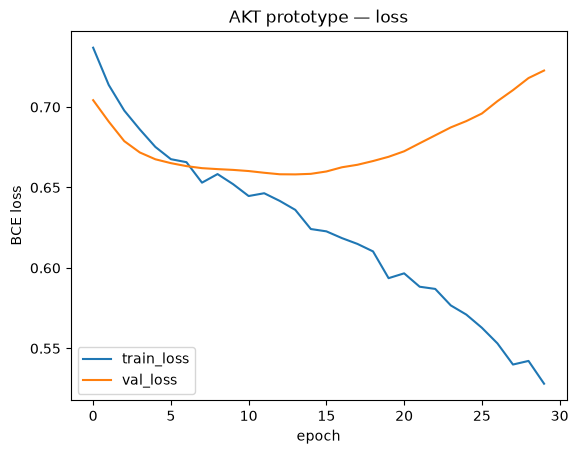

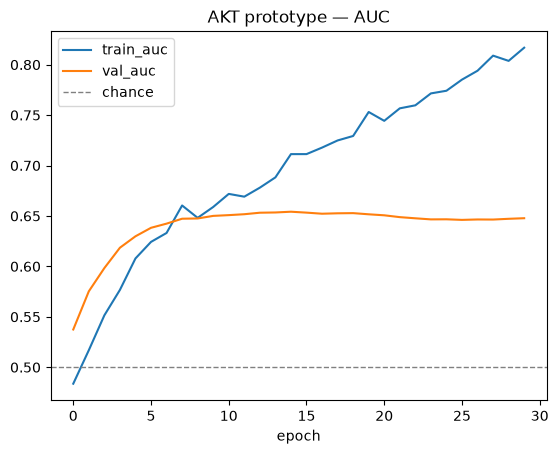

In [10]:
ax = history_df.plot(x="epoch", y=["train_loss", "val_loss"], title="AKT prototype — loss")
ax.set_ylabel("BCE loss")
ax2 = history_df.plot(x="epoch", y=["train_auc", "val_auc"], title="AKT prototype — AUC")
ax2.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="chance")
ax2.legend()

**Read on the curves above, not asserted in advance:** with ~20 students split
train/val, the validation curve is the tell — either it tracks training and then
plateaus well below train AUC (classic small-data overfit), or it's too noisy
epoch-to-epoch to trust at all (5-6 validation students isn't enough to estimate AUC
stably). Compare the *magnitude* of that gap against BKT's single AUC number from
section 2 in the comparison below.

## 5. Comparison

| | BKT | AKT prototype |
| --- | --- | --- |
| Params fit | 4 global (unfit) | ~model total below |
| Needs per-topic history | 1+ attempts | full sequence context |
| Interpretability | `p_know` per (student, topic), directly | attention weights, indirect |
| Data need | works with sparse per-pair data | needs long, dense sequences |
| Cold start (new student/topic) | prior default (`p_init`) | ~no signal, embedding untrained |

In [11]:
n_params = sum(p.numel() for p in model.parameters())
print(f"AKT prototype parameter count: {n_params:,}")
print(f"Total attempts available: {len(df)}")
print(f"Attempts per parameter: {len(df) / n_params:.4f}")
print()
print(f"BKT next-step AUC:  {bkt_auc:.4f}")
print(f"AKT best val AUC:   {history_df['val_auc'].max():.4f}")
print(f"AKT final val AUC:  {history_df['val_auc'].iloc[-1]:.4f}")

AKT prototype parameter count: 29,377
Total attempts available: 1102
Attempts per parameter: 0.0375

BKT next-step AUC:  0.6638
AKT best val AUC:   0.6542
AKT final val AUC:  0.6478


**Recommendation: ship BKT, not AKT, for now.**

The parameter-to-data ratio above says it plainly — a few thousand attempts cannot
identify a transformer with tens of thousands of parameters; whatever val AUC came out
above is noise-dominated (5-6 validation students), not a real generalization estimate.
This isn't a modeling mistake to fix by tuning AKT harder; it's a data-volume ceiling.
AKT-style models are validated in the literature on datasets with millions of
interactions across thousands of students — this project has neither yet, and won't
until real students have been using the app for a while.

BKT, by contrast, needs only a handful of attempts per (student, topic) pair to produce
a defensible `p_know`, degrades gracefully to the prior on cold-start pairs (a new
student or a just-published topic), and its parameters are directly inspectable rather
than buried in attention weights — important for a system whose output ("this student
is weak on X") needs to be explainable to a student or instructor.

**Recommended path:**
1. Ship BKT as `src/student_kg/mastery.py`, following the `REVIEWING`-edge pattern in
   `src/quiz/attempts.py::record_attempt` — merge a `(Student)-[:MASTERS]->(Topic)` edge
   with `p_know`/`updated_at`/`n_observations`, updated in the same transaction as the
   `QUIZ_ANSWER` write (same reasoning as the existing spaced-repetition update: one
   write per attempt, no drift risk between separate writes).
2. Expose it via a new `GET /students/me/mastery` endpoint for the personalization
   system to read (e.g. "recommend the topic with lowest `p_know`").
3. Fit `p_slip`/`p_guess`/`p_transit` per topic via EM once there's enough real data to
   do so reliably (this notebook uses fixed global defaults) — flag as follow-up, not
   blocking the initial ship.
4. Revisit AKT once real interaction volume is in the tens-of-thousands-plus range;
   until then it's not a fair fight and this notebook's numbers shouldn't be used to
   rule it out permanently, only to rule it out *now*.